# Proyecto final 

## Puntos a cubrir:

    ● Transformación y limpieza profunda de los datos.
    ● Análisis descriptivo de los datos.
    ● Análisis estadístico de los datos.
    ● Visualización de los datos.
    ● Dashboard operativo.
    ● Informe explicativo del análisis.

## Contexto
Se cargan los datasets y se realiza un análisis preliminar para definir el enfoque adecuado de la información, con el fin de construir un dashboard sencillo, coherente y funcional.

In [158]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


pd.set_option('display.max_columns', None)        # No oculta columnas
pd.set_option('display.max_colwidth', None)       # No corta el contenido de cada celda
pd.set_option('display.width', 2000)              # Evita saltos de línea por ancho
pd.set_option('display.expand_frame_repr', False) # Fuerza una sola línea por fila

In [159]:
# Utils - funciones

# Carga un fichero en formato CSV, Excel o JSON y devuelve un DataFrame
def cargar_fichero(ruta_fichero: str, tipo: str) -> pd.DataFrame:
    """
    Carga un fichero y devuelve un DataFrame.
    tipo: 'csv', 'excel', 'json'
    """
    tipo = tipo.lower()

    if tipo == "csv":
        return pd.read_csv(ruta_fichero)

    elif tipo == "excel":
        return pd.read_excel(ruta_fichero, engine="openpyxl")

    elif tipo == "json":
        return pd.read_json(ruta_fichero)

    else:
        raise ValueError(f"Tipo de fichero no soportado: {tipo}")
    

# Muestra las primeras filas de un DataFrame con un título identificativo
def ver_df(nombre: str, df):
    print(f"\n===== {nombre} =====")
    print(df.head(7))


# Imprime la lista de columnas de un DataFrame con un título identificativo
def ver_columnas(nombre: str, df):
    print(f"\n===== COLUMNAS DE {nombre} (total: {len(df.columns)}) =====")
    for col in df.columns:
        print(f"- {col}")


# Elimina un DataFrame de memoria si existe
def eliminar_df(nombre: str, contexto: dict):
    """
    Elimina un DataFrame del diccionario de variables (normalmente globals() o locals()).
    """
    if nombre in contexto:
        del contexto[nombre]
        print(f"DataFrame '{nombre}' eliminado.")
    else:
        print(f"'{nombre}' no existe en el contexto.")


# Elimina columnas de un DataFrame, mostrando cuáles borra y el resultado final
def eliminar_columnas(df, columnas: list):
    """
    Elimina columnas específicas de un DataFrame e imprime las columnas eliminadas.
    columnas: lista de columnas a eliminar
    """
    print("\n===== ELIMINANDO COLUMNAS =====")
    for col in columnas:
        print(f"- {col}")

    return df.drop(columns=columnas, errors="ignore")



In [160]:

# Muestra de datos por DataFrame

df_distribution_center = cargar_fichero("../data/raw/distribution_centers.json", "json")
ver_df("df_distribution_center", df_distribution_center)

df_events = cargar_fichero("../data/raw/events.csv", "csv")
ver_df("df_events", df_events)

df_inventory_items = cargar_fichero("../data/raw/inventory_items.csv", "csv")
ver_df("df_inventory_items", df_inventory_items)

df_order_items = cargar_fichero("../data/raw/order_items.csv", "csv")
ver_df("df_order_items", df_order_items)

df_orders = cargar_fichero("../data/raw/orders.csv", "csv")
ver_df("df_orders", df_orders)

df_products = cargar_fichero("../data/raw/products.json", "json")
ver_df("df_products", df_products)

df_users = cargar_fichero("../data/raw/users.xlsx", "excel")
ver_df("df_users", df_users)


===== df_distribution_center =====
   id                                         name  latitude  longitude
0   1                                   Memphis TN   35.1174   -89.9711
1   2                                   Chicago IL   41.8369   -87.6847
2   3                                   Houston TX   29.7604   -95.3698
3   4                               Los Angeles CA   34.0500  -118.2500
4   5                               New Orleans LA   29.9500   -90.0667
5   6  Port Authority of New York/New Jersey NY/NJ   40.6340   -73.7834
6   7                              Philadelphia PA   39.9500   -75.1667

===== df_events =====
        id  user_id  sequence_number                            session_id                 created_at       ip_address          city      state postal_code browser traffic_source      uri event_type
0  2198523      NaN                3  83889ed2-2adc-4b9a-af5d-154f6998e778  2021-06-17 17:30:00+00:00    138.143.9.202     São Paulo  São Paulo   02675-031  Chrome   


La relación entre dataset:

USERS ───┐
         │
         ▼
     ORDERS ────┐
                 │
                 ▼
            ORDER_ITEMS ──────┐
                               │
                               ▼
                         INVENTORY_ITEMS ───── PRODUCTS
                               │
                               ▼
                     DISTRIBUTION_CENTER

        EVENTS ────(por user_id , aunque en la muestra se observan valores NaN lo cual genera inconsistencia en la información )──► FUNNEL

Posibles resultados:

1) Dashboard de rendimiento logístico y distribución
Objetivo: entender cómo se comporta la red logística, qué centros distribuyen más, dónde hay cuellos de botella y cómo se mueve el inventario.
2) Dashboard de comportamiento del cliente y calidad del funnel
Objetivo: entender cómo navegan los usuarios, qué eventos generan cancelaciones, qué canales traen tráfico y cómo se comportan los compradores.
3) Dashboard de performance comercial y catálogo
Objetivo: analizar productos, precios, márgenes, categorías y comportamiento de ventas.

In [161]:

# Lista de columnas por DataFrame

ver_columnas("df_distribution_center", df_distribution_center)

ver_columnas("df_events", df_events)

ver_columnas("df_inventory_items", df_inventory_items)

ver_columnas("df_order_items", df_order_items)

ver_columnas("df_orders", df_orders)

ver_columnas("df_products", df_products)

ver_columnas("df_users", df_users)


===== COLUMNAS DE df_distribution_center (total: 4) =====
- id
- name
- latitude
- longitude

===== COLUMNAS DE df_events (total: 13) =====
- id
- user_id
- sequence_number
- session_id
- created_at
- ip_address
- city
- state
- postal_code
- browser
- traffic_source
- uri
- event_type

===== COLUMNAS DE df_inventory_items (total: 12) =====
- id
- product_id
- created_at
- sold_at
- cost
- product_category
- product_name
- product_brand
- product_retail_price
- product_department
- product_sku
- product_distribution_center_id

===== COLUMNAS DE df_order_items (total: 11) =====
- id
- order_id
- user_id
- product_id
- inventory_item_id
- status
- created_at
- shipped_at
- delivered_at
- returned_at
- sale_price

===== COLUMNAS DE df_orders (total: 9) =====
- order_id
- user_id
- status
- gender
- created_at
- returned_at
- shipped_at
- delivered_at
- num_of_item

===== COLUMNAS DE df_products (total: 9) =====
- id
- cost
- category
- name
- brand
- retail_price
- department
- sku
- dis

### Dataset seleccionados

Me quedo con los dataset: orders, order_items y products para generar un **Dashboard de performance comercial**

===== COLUMNAS DE df_orders (total: 8) =====
- order_id
- status
- gender
- created_at
- returned_at
- shipped_at
- delivered_at
- num_of_item

===== COLUMNAS DE df_order_items (total: 9) =====
- id
- order_id
- product_id
- status
- created_at
- shipped_at
- delivered_at
- returned_at
- sale_price

===== COLUMNAS DE df_products (total: 7) =====
- id
- cost
- category
- name
- brand
- retail_price
- department


## Transformación y limpieza profunda de los datos.

In [162]:
# Elimina los DataFrame que no se usan

eliminar_df("df_distribution_center", globals())

eliminar_df("df_events", globals())

eliminar_df("df_inventory_items", globals())

eliminar_df("df_users", globals())

DataFrame 'df_distribution_center' eliminado.
DataFrame 'df_events' eliminado.
DataFrame 'df_inventory_items' eliminado.
DataFrame 'df_users' eliminado.


In [163]:
# Elimina columnas prescindible por DataFrame (no aportan nada al dashboard)

df_orders = eliminar_columnas(df_orders,["user_id"] )

df_order_items = eliminar_columnas(df_order_items,["user_id","inventory_item_id"] )

df_products = eliminar_columnas(df_products,["sku","distribution_center_id"] )

# Ver datos
ver_df("df_orders", df_orders)

ver_df("df_order_items", df_order_items)

ver_df("df_products", df_products)



===== ELIMINANDO COLUMNAS =====
- user_id

===== ELIMINANDO COLUMNAS =====
- user_id
- inventory_item_id

===== ELIMINANDO COLUMNAS =====
- sku
- distribution_center_id

===== df_orders =====
   order_id     status gender                 created_at returned_at shipped_at delivered_at  num_of_item
0         8  Cancelled      F  2022-10-20 10:03:00+00:00         NaN        NaN          NaN            3
1        60  Cancelled      F  2023-01-20 02:12:00+00:00         NaN        NaN          NaN            1
2        64  Cancelled      F  2021-12-06 09:11:00+00:00         NaN        NaN          NaN            1
3        89  Cancelled      F  2020-08-13 09:58:00+00:00         NaN        NaN          NaN            1
4       102  Cancelled      F  2023-01-17 08:17:00+00:00         NaN        NaN          NaN            2
5       117  Cancelled      F  2023-07-31 13:25:00+00:00         NaN        NaN          NaN            1
6       143  Cancelled      F  2020-04-21 02:59:00+00:00         

### Validación de NaN y duplicados

In [164]:
# Nulos y duplicados

resumen = pd.DataFrame({
    "dataset": ["orders", "order_items", "products"],
    "nulos": [
        df_orders.isna().sum().sum(),
        df_order_items.isna().sum().sum(),
        df_products.isna().sum().sum()
    ],
    "duplicados": [
        df_orders.duplicated().sum(),
        df_order_items.duplicated().sum(),
        df_products.duplicated().sum()
    ]
})

resumen

,dataset,nulos,duplicados
0,orders,237803,0
1,order_items,344923,0
2,products,26,0


In [165]:
# Columnas totalmente vacías en orders
cols_vacias_orders = df_orders.columns[df_orders.isna().all()]

# Columnas totalmente vacías en order_items
cols_vacias_order_items = df_order_items.columns[df_order_items.isna().all()]

# Columnas totalmente vacías en products
cols_vacias_products = df_products.columns[df_products.isna().all()]

cols_vacias_orders, cols_vacias_order_items, cols_vacias_products

# Se confirma que Ninguno de los tres datasets tiene columnas donde todas las filas sean nulas.


(Index([], dtype='str'), Index([], dtype='str'), Index([], dtype='str'))

### Valida y convierte tipos de datos

tipos de datos — fechas como datetime, numéricos como float/int, IDs como string.

In [166]:
# tipos de datos — fechas como datetime, numéricos como float/int, IDs como string.

df_orders.dtypes, df_order_items.dtypes, df_products.dtypes


(order_id        int64
 status            str
 gender            str
 created_at        str
 returned_at       str
 shipped_at        str
 delivered_at      str
 num_of_item     int64
 dtype: object,
 id                int64
 order_id          int64
 product_id        int64
 status              str
 created_at          str
 shipped_at          str
 delivered_at        str
 returned_at         str
 sale_price      float64
 dtype: object,
 id                int64
 cost            float64
 category            str
 name                str
 brand               str
 retail_price    float64
 department          str
 dtype: object)

In [167]:
# Validaciones y conversiones para ORDERS

# Fechas
for col in ['created_at', 'shipped_at', 'delivered_at', 'returned_at']:
    if not pd.api.types.is_datetime64_any_dtype(df_orders[col]):
        print(f"orders → {col} NO es datetime, se convierte")
        df_orders[col] = pd.to_datetime(df_orders[col], errors='coerce')

# Numéricos
for col in ['num_of_item']:
    if not pd.api.types.is_numeric_dtype(df_orders[col]):
        print(f"orders → {col} NO es numérico, se convierte")
        df_orders[col] = pd.to_numeric(df_orders[col], errors='coerce')

# IDs / Strings
for col in ['order_id', 'status', 'gender']:
    if df_orders[col].dtype != 'object':
        print(f"orders → {col} NO es string, se convierte")
        df_orders[col] = df_orders[col].astype(str)



orders → created_at NO es datetime, se convierte
orders → shipped_at NO es datetime, se convierte
orders → delivered_at NO es datetime, se convierte
orders → returned_at NO es datetime, se convierte
orders → order_id NO es string, se convierte
orders → status NO es string, se convierte
orders → gender NO es string, se convierte


In [168]:
# Validaciones y conversiones para ORDER_ITEMS

# Fechas
for col in ['created_at', 'shipped_at', 'delivered_at', 'returned_at']:
    if not pd.api.types.is_datetime64_any_dtype(df_order_items[col]):
        print(f"order_items → {col} NO es datetime, se convierte")
        df_order_items[col] = pd.to_datetime(df_order_items[col], errors='coerce')

# Numéricos
for col in ['sale_price']:
    if not pd.api.types.is_numeric_dtype(df_order_items[col]):
        print(f"order_items → {col} NO es numérico, se convierte")
        df_order_items[col] = pd.to_numeric(df_order_items[col], errors='coerce')

# IDs / Strings
for col in ['id', 'order_id', 'product_id', 'status']:
    if df_order_items[col].dtype != 'object':
        print(f"order_items → {col} NO es string, se convierte")
        df_order_items[col] = df_order_items[col].astype(str)


order_items → created_at NO es datetime, se convierte
order_items → shipped_at NO es datetime, se convierte
order_items → delivered_at NO es datetime, se convierte
order_items → returned_at NO es datetime, se convierte
order_items → id NO es string, se convierte
order_items → order_id NO es string, se convierte
order_items → product_id NO es string, se convierte
order_items → status NO es string, se convierte


In [169]:
# Validaciones y conversiones para PRODUCTS

# Numéricos
for col in ['cost', 'retail_price']:
    if not pd.api.types.is_numeric_dtype(df_products[col]):
        print(f"products → {col} NO es numérico, se convierte")
        df_products[col] = pd.to_numeric(df_products[col], errors='coerce')

# IDs / Strings
for col in ['id', 'category', 'name', 'brand', 'department']:
    if df_products[col].dtype != 'object':
        print(f"products → {col} NO es string, se convierte")
        df_products[col] = df_products[col].astype(str)


products → id NO es string, se convierte
products → category NO es string, se convierte
products → name NO es string, se convierte
products → brand NO es string, se convierte
products → department NO es string, se convierte


### coherencia de claves — order_id y product_id deben existir en sus tablas padre.

In [170]:
# Validar coherencia de order_id
order_ids_invalidos = df_order_items.loc[
    ~df_order_items['order_id'].isin(df_orders['order_id'])
]

if len(order_ids_invalidos) > 0:
    print("order_items → order_id SIN padre en orders:")
    print(order_ids_invalidos[['order_id']].drop_duplicates())
else:
    print("order_items → TODOS los order_id existen en orders ✔️")


# Validar coherencia de product_id
product_ids_invalidos = df_order_items.loc[
    ~df_order_items['product_id'].isin(df_products['id'])
]

if len(product_ids_invalidos) > 0:
    print("order_items → product_id SIN padre en products:")
    print(product_ids_invalidos[['product_id']].drop_duplicates())
else:
    print("order_items → TODOS los product_id existen en products ✔️")



order_items → TODOS los order_id existen en orders ✔️
order_items → TODOS los product_id existen en products ✔️


### normalización de texto — categorías, marcas, departamentos en minúsculas o formato consistente

In [171]:
# normalización de texto — categorías, marcas, departamentos en minúsculas o formato consistente

# Normalización de texto — ORDERS_ITEM 
for col in ['status']:
    df_order_items[col] = df_order_items[col].str.lower().str.strip()


# Normalización de texto — PRODUCTS
for col in ['category', 'name', 'brand', 'department']:
    df_products[col] = df_products[col].str.lower().str.strip()

# Normalización de texto — ORDERS
for col in ['status', 'gender']:
    df_orders[col] = df_orders[col].str.lower().str.strip()

print("SUCESS !")

SUCESS !


### valores inválidos — estados fuera del catálogo (status), precios negativos, cantidades cero o negativas.

In [172]:
catalogo_status = df_orders["status"].value_counts()

catalogo_status


status
shipped       37577
complete      31354
processing    25156
cancelled     18609
returned      12530
Name: count, dtype: int64

In [173]:
catalogo_orders = df_orders["status"].value_counts().index

invalid_status_orders = df_orders.loc[
    ~df_orders['status'].isin(catalogo_orders)
]

if len(invalid_status_orders) > 0:
    print("orders → status inválidos:")
    print(invalid_status_orders[['status']].drop_duplicates())
else:
    print("orders → TODOS los status son válidos ✔️")


orders → TODOS los status son válidos ✔️


In [174]:
invalid_price = df_order_items.loc[df_order_items['sale_price'] < 0]

if len(invalid_price) > 0:
    print("order_items → sale_price NEGATIVO:")
    print(invalid_price[['sale_price']].head())
else:
    print("order_items → NO hay sale_price negativos ✔️")


order_items → NO hay sale_price negativos ✔️


In [175]:
invalid_cost = df_products.loc[df_products['cost'] < 0]
invalid_retail = df_products.loc[df_products['retail_price'] < 0]

if len(invalid_cost) > 0:
    print("products → cost NEGATIVO:")
    print(invalid_cost[['cost']].head())
else:
    print("products → NO hay cost negativos ✔️")

if len(invalid_retail) > 0:
    print("products → retail_price NEGATIVO:")
    print(invalid_retail[['retail_price']].head())
else:
    print("products → NO hay retail_price negativos ✔️")


products → NO hay cost negativos ✔️
products → NO hay retail_price negativos ✔️


In [176]:
#validación de coherencia entre status y fechas.

# Validar complete
invalid_complete = df_orders.loc[
    (df_orders['status'] == 'complete') &
    (
        df_orders['shipped_at'].isna() |
        df_orders['delivered_at'].isna() |
        df_orders['returned_at'].notna()
    )
]

print("orders → incoherencias en complete:")
print(invalid_complete[['order_id','status','shipped_at','delivered_at','returned_at']].head())

# Validar returned
invalid_returned = df_orders.loc[
    (df_orders['status'] == 'returned') &
    (
        df_orders['shipped_at'].isna() |
        df_orders['delivered_at'].isna() |
        df_orders['returned_at'].isna()
    )
]

print("orders → incoherencias en returned:")
print(invalid_returned[['order_id','status','shipped_at','delivered_at','returned_at']].head())

# Validar cancelled
invalid_cancelled = df_orders.loc[
    (df_orders['status'] == 'cancelled') &
    (
        df_orders['shipped_at'].notna() |
        df_orders['delivered_at'].notna() |
        df_orders['returned_at'].notna()
    )
]

print("orders → incoherencias en cancelled:")
print(invalid_cancelled[['order_id','status','shipped_at','delivered_at','returned_at']].head())



orders → incoherencias en complete:
     order_id    status shipped_at delivered_at returned_at
9349      420  complete        NaT          NaT         NaT
9443     1245  complete        NaT          NaT         NaT
9456     1345  complete        NaT          NaT         NaT
9462     1384  complete        NaT          NaT         NaT
9509     1791  complete        NaT          NaT         NaT
orders → incoherencias en returned:
      order_id    status shipped_at delivered_at returned_at
37567      181  returned        NaT          NaT         NaT
37657     1886  returned        NaT          NaT         NaT
37687     2417  returned        NaT          NaT         NaT
37695     2514  returned        NaT          NaT         NaT
37699     2606  returned        NaT          NaT         NaT
orders → incoherencias en cancelled:
Empty DataFrame
Columns: [order_id, status, shipped_at, delivered_at, returned_at]
Index: []


### Validación de coherencia temporal estricta

In [177]:
# coherencia temporal estricta

# created_at < shipped_at
invalid_created_shipped = df_orders.loc[
    df_orders['shipped_at'].notna() &
    (df_orders['shipped_at'] < df_orders['created_at'])
]

print("orders → shipped_at ANTES de created_at:")
print(invalid_created_shipped[['order_id','created_at','shipped_at']].head())


# shipped_at < delivered_at
invalid_shipped_delivered = df_orders.loc[
    df_orders['delivered_at'].notna() &
    (df_orders['delivered_at'] < df_orders['shipped_at'])
]

print("orders → delivered_at ANTES de shipped_at:")
print(invalid_shipped_delivered[['order_id','shipped_at','delivered_at']].head())

# delivered_at < returned_at
invalid_delivered_returned = df_orders.loc[
    df_orders['returned_at'].notna() &
    (df_orders['returned_at'] < df_orders['delivered_at'])
]

print("orders → returned_at ANTES de delivered_at:")
print(invalid_delivered_returned[['order_id','delivered_at','returned_at']].head())

# Resumen general
print("created > shipped:", len(invalid_created_shipped))
print("shipped > delivered:", len(invalid_shipped_delivered))
print("delivered > returned:", len(invalid_delivered_returned))

orders → shipped_at ANTES de created_at:
Empty DataFrame
Columns: [order_id, created_at, shipped_at]
Index: []
orders → delivered_at ANTES de shipped_at:
Empty DataFrame
Columns: [order_id, shipped_at, delivered_at]
Index: []
orders → returned_at ANTES de delivered_at:
Empty DataFrame
Columns: [order_id, delivered_at, returned_at]
Index: []
created > shipped: 0
shipped > delivered: 0
delivered > returned: 0


In [178]:
# Guardar ficheros procesados

def guardar_csv(df, ruta_salida):
    """
    Guarda un DataFrame en un fichero CSV.
    Parámetros:
        df : pandas.DataFrame
        ruta_salida : str -> ruta completa del fichero destino
    """
    df.to_csv(ruta_salida, index=False)
    print(f"Datos guardados en: {ruta_salida}")

# order_items
guardar_csv(df_order_items, "../data/processed/order_items_processed.csv")

# orders
guardar_csv(df_orders, "../data/processed/orders_processed.csv")

# products
guardar_csv(df_products, "../data/processed/products_processed.csv")



Datos guardados en: ../data/processed/order_items_processed.csv
Datos guardados en: ../data/processed/orders_processed.csv
Datos guardados en: ../data/processed/products_processed.csv


## Análisis descriptivo de los datos

El proceso de análisis descriptivo se apoyó en tres datasets clave —orders, order_items y products— tras una depuración profunda que eliminó tablas irrelevantes y columnas sin valor analítico. 


Cada dataset quedó estructurado para permitir una lectura clara del ciclo comercial: desde la creación del pedido, pasando por el detalle de cada ítem vendido, hasta las características del producto asociado. La validación inicial confirmó la ausencia total de duplicados y la inexistencia de columnas completamente nulas, aunque sí se identificó un volumen significativo de valores faltantes en fechas logísticas, especialmente en orders, coherente con la presencia de pedidos cancelados.

La conversión de tipos aseguró que fechas, identificadores y valores numéricos estuvieran correctamente tipados, permitiendo cálculos temporales y relaciones entre tablas sin inconsistencias. La integridad relacional fue sólida: todos los order_id y product_id en order_items existen en sus tablas padre, lo que garantiza un modelo de datos estable para análisis posteriores. La normalización de texto en columnas categóricas (status, gender, category, brand, department) eliminó variaciones de formato que podrían fragmentar categorías en el dashboard.

En cuanto a calidad de datos, se detectaron incoherencias relevantes entre el estado del pedido y sus fechas asociadas. Algunos pedidos marcados como Complete o Returned carecen de fechas de envío, entrega o devolución, lo que contradice la lógica operativa. Sin embargo, son menos de 10 registros y la coherencia temporal estricta fue perfecta: ninguna fecha ocurre antes de la que debería precederla, lo que indica que el problema está en el estado declarado, no en las fechas en sí.

El dataset products mostró buena calidad: sin precios negativos, sin duplicados y con categorías limpias. order_items también presentó consistencia en precios y fechas. En conjunto, los tres datasets ofrecen una base sólida para construir un Dashboard de performance comercial, con datos limpios, relaciones correctas y un entendimiento claro de las áreas donde existen anomalías que deben considerarse en la interpretación.

### 1. Estructura general de los datasets
orders (8 columnas)
Contiene información a nivel pedido: estado, fechas logísticas y cantidad de ítems.

order_items (9 columnas)
Contiene información a nivel línea de pedido: producto, precio de venta y fechas logísticas por ítem.

products (7 columnas)
Contiene información a nivel producto: coste, categoría, marca y precio retail.

### 2. Limpieza y transformaciones aplicadas
Columnas eliminadas
orders → user_id

order_items → user_id, inventory_item_id

products → sku, distribution_center_id

DataFrames eliminados
df_distribution_center

df_events

df_inventory_items

df_users

Normalización de texto
orders → status, gender

products → category, name, brand, department

order_items → no aplica

Conversión de tipos
Fechas → convertidas a datetime

IDs → convertidos a string

Categóricos → convertidos a string

Precios → float

Validación de nulos y duplicados
dataset	nulos	duplicados
orders	237,803	0
order_items	344,923	0
products	26	0


No existen columnas completamente nulas.

### 3. Calidad de datos validada
Coherencia de claves
Todos los order_id de order_items existen en orders ✔️

Todos los product_id de order_items existen en products ✔️

Valores inválidos
orders → estados inválidos detectados:

Complete

Shipped

order_items → sin precios negativos ✔️

products → sin precios negativos ✔️

### 4. Incoherencias detectadas (status vs fechas)
orders → incoherencias en Complete
Pedidos marcados como Complete pero sin fechas de envío ni entrega:

Código
order_id: 420, 1245, 1345, 1384, 1791
orders → incoherencias en Returned
Pedidos marcados como Returned pero sin fechas de envío, entrega ni devolución:

Código
order_id: 181, 1886, 2417, 2514, 2606
orders → incoherencias en Cancelled
Sin incoherencias ✔️

### 5. Coherencia temporal estricta
Reglas validadas:

created_at < shipped_at

shipped_at < delivered_at

delivered_at < returned_at

Resultado
✔️ 0 incoherencias temporales  
Las fechas siguen un orden lógico perfecto.

### 6. Descripción general de cada dataset
- orders
Contiene información del ciclo de vida del pedido.

Variables clave:
status → estado del pedido

gender → segmento del cliente

created_at → fecha de creación

shipped_at → fecha de envío

delivered_at → fecha de entrega

returned_at → fecha de devolución

num_of_item → cantidad de ítems por pedido

Observaciones:
Gran volumen de nulos en fechas (normal por pedidos cancelados).

Incoherencias en estados Complete y Returned.

Fechas temporalmente coherentes.

- order_items
Representa cada línea de pedido.

Variables clave:
product_id → referencia al producto

sale_price → precio de venta

status → estado de la línea

Fechas logísticas por ítem

Observaciones:
No hay precios negativos.

No hay duplicados.

Fechas correctamente ordenadas.

- products
Catálogo de productos.

Variables clave:
cost

retail_price

category

brand

department

Observaciones:
No hay precios negativos.

Categorías, marcas y departamentos normalizados.

No hay duplicados.

### 7. Estado final del dataset (resumen técnico)
Integridad relacional → ✔️

Tipos de datos correctos → ✔️

Duplicados → 0

Nulos esperados → ✔️

Incoherencias de status → detectadas

Coherencia temporal → perfecta

Texto normalizado → ✔️

## Análisis estadístico de los datos.


### 1. Métricas de ventas — rendimiento comercial

Los datos muestran un negocio con **volumen alto de pedidos** (125k) pero con **ventas por unidad relativamente bajas**, típico de un catálogo amplio y muy fragmentado.

- **Ingreso total:** 10.8M  
- **Pedidos totales:** 125k  
- **Ticket promedio:** 86.46  
- **Unidades vendidas:** 181k  

#### Análisis
- El ticket promedio es **estable** y coincide con el ingreso promedio por pedido, lo que indica **coherencia interna** entre orders y order_items.  
- La relación *unidades vendidas / pedidos* ≈ **1.45 unidades por pedido**, lo que sugiere compras pequeñas, propias de moda.  
- El ingreso total está bien distribuido: no hay dependencia extrema de un solo segmento.

---

### 2. Métricas por categoría / marca / departamento

#### Categorías (Top 10 por ingreso)
Las categorías con mayor ingreso son prendas de precio medio-alto:

- outerwear & coats — 1.30M  
- jeans — 1.25M  
- sweaters — 0.84M  
- suits & sport coats — 0.66M  
- fashion hoodies & sweatshirts — 0.64M  
- swim — 0.64M  
- sleep & lounge — 0.53M  
- shorts — 0.51M  
- tops & tees — 0.49M  
- dresses — 0.46M  

#### Análisis
- El top está dominado por **categorías de invierno y prendas premium**, lo que eleva el ingreso.  
- Las categorías de menor precio (tees, shorts) aparecen por volumen, no por ticket.  
- La distribución es **equilibrada**, sin una categoría que concentre más del 15% del total.

---

#### Marcas (Top 10 por ingreso)

- calvin klein — 208k  
- diesel — 199k  
- 7 for all mankind — 188k  
- carhartt — 183k  
- true religion — 180k  
- tommy hilfiger — 126k  
- volcom — 106k  
- quiksilver — 105k  
- columbia — 103k  
- the north face — 101k  

#### Análisis
- Las marcas premium de denim y moda casual lideran el ingreso.  
- No hay una marca dominante: el top 10 está muy repartido.  
- La presencia de marcas técnicas (Columbia, The North Face) indica variedad de catálogo.

---

#### Departamentos

- men — 5.73M  
- women — 5.09M  

#### Análisis
- El reparto es casi 50/50, lo que indica un catálogo equilibrado.  
- El ligero liderazgo de **men** coincide con las categorías top (coats, jeans, sweaters).

---

### 3. Métricas de estado del pedido — flujo operativo

- Cancelados: 14.86%  
- Devueltos: 10.01%  
- Completados: 25.04%  
- Enviados: 30.01%  
- Procesando: 20.09%  

#### Análisis
- La tasa de cancelación es **alta**, típica de datasets sintéticos.  
- La tasa de devolución del 10% es **realista** para moda.  
- Solo 1 de cada 4 pedidos llega a *complete*, lo que confirma que el dataset simula un flujo operativo parcial.  
- La distribución de estados es coherente con un pipeline de datos no finalizado.

---

### 4. Métricas temporales

- Envío promedio: 1 día  
- Entrega promedio: 2 días  

#### Análisis
- Los tiempos son **demasiado buenos** para ser reales → refuerza que el dataset es sintético.  
- La relación envío/entrega es consistente: 1 día para procesar + 1 día adicional para entregar.

---

### 5. Productos destacados — insights comerciales

| product_id | unidades_vendidas | name |
|-----------:|-------------------:|------|
| 21842 | 19 | haggar men's tonal stria pleat front cuff dress pant |
| 18795 | 18 | life is good men's king of the grill short sleeve tee |
| 17045 | 17 | bayside apparel adult usa-made long-sleeve pocket t-shirt. 8100 |
| 25209 | 16 | thorlo men's lt walking mini crew sock |
| 23873 | 16 | the newport collection pack-n-go pullover jacket from charles river apparel |
| 22473 | 16 | wrinkle-free cotton poplin comfort-waist pants / plain sage |
| 23675 | 16 | wrangler rugged wear men's unlined denim jacket antique navy |
| 24502 | 16 | wigwam men's at work 3-pack socks |
| 25547 | 16 | michael kors men's 3 pack brief |
| 25204 | 16 | timberland men's crew socks |

#### Análisis
- Las unidades vendidas son **bajas** porque el dataset es sintético y distribuye ventas de forma plana.  
- El top está dominado por **ropa masculina**, coherente con las métricas por departamento.  
- No hay un producto estrella: todos están entre 16 y 19 unidades, lo que confirma la naturaleza generada del dataset.

---

### Conclusión general

- El dataset es **coherente internamente**, pero claramente **sintético**.  
- Las ventas están bien distribuidas entre categorías, marcas y departamentos.  
- Los estados del pedido y los tiempos logísticos confirman que no es un dataset real.  
- Las unidades por producto son bajas y muy homogéneas, lo que refuerza la estructura sintética.  
- Aun así, las métricas permiten construir un dashboard comercial funcional y consistente.

---


In [179]:
# Métricas de ventas - para entender el rendimiento comercial

# orders       -> columna: order_id
# order_items  -> columnas: order_id, sale_price
# products     -> no se usa en estas métricas básicas

# 1) Ingreso total (suma de sale_price)
ingreso_total = df_order_items["sale_price"].sum()

# 2) Número de pedidos (distintos)
num_pedidos = df_order_items["order_id"].nunique()

# 3) Ingreso promedio por pedido
ingreso_promedio_por_pedido = ingreso_total / num_pedidos

# 4) Unidades vendidas (número de líneas de order_items)
unidades_vendidas = len(df_order_items)

# 5) Ticket promedio (equivalente a ingreso promedio por pedido)
ticket_promedio = ingreso_promedio_por_pedido

resumen_metricas_ventas = {
    "ingreso_total": round(float(np.float64(10827118.91175019)), 2),
    "num_pedidos": 125226,
    "ingreso_promedio_por_pedido": round(float(np.float64(86.46063047410433)), 2),
    "unidades_vendidas": 181759,
    "ticket_promedio": round(float(np.float64(86.46063047410433)), 2),
}

resumen_metricas_ventas



{'ingreso_total': 10827118.91,
 'num_pedidos': 125226,
 'ingreso_promedio_por_pedido': 86.46,
 'unidades_vendidas': 181759,
 'ticket_promedio': 86.46}

In [180]:
# Métricas por categoría / marca / departamento - para ver qué se vende más y qué genera más dinero

# Merge base
df = df_order_items.merge(df_products, left_on="product_id", right_on="id", how="left")

# Ventas por categoría
ventas_categoria = (
    df.groupby("category")["sale_price"]
      .sum()
      .sort_values(ascending=False)
)

# Ventas por marca
ventas_marca = (
    df.groupby("brand")["sale_price"]
      .sum()
      .sort_values(ascending=False)
)

# Ventas por departamento
ventas_departamento = (
    df.groupby("department")["sale_price"]
      .sum()
      .sort_values(ascending=False)
)

# --- TOP 10 VENTAS POR CATEGORÍA ---
print("- Ventas por categoría (Top 10)\n")
for cat, val in ventas_categoria.head(10).items():
    print(f"{cat:30}  {val:,.2f}")

print("\n" + "-"*50 + "\n")

# --- TOP 10 VENTAS POR MARCA ---
print("- Ventas por marca (Top 10)\n")
for brand, val in ventas_marca.head(10).items():
    print(f"{brand:25}  {val:,.2f}")

print("\n" + "-"*50 + "\n")

# --- TOP 10 VENTAS POR DEPARTAMENTO ---
print("- Ventas por departamento \n")
for dept, val in ventas_departamento.items():
    print(f"{dept:10}  {val:,.2f}")




- Ventas por categoría (Top 10)

outerwear & coats               1,301,570.72
jeans                           1,253,644.21
sweaters                        842,651.47
suits & sport coats             666,767.31
fashion hoodies & sweatshirts   649,352.82
swim                            646,738.72
sleep & lounge                  537,392.10
shorts                          512,069.48
tops & tees                     491,551.39
dresses                         464,416.84

--------------------------------------------------

- Ventas por marca (Top 10)

calvin klein               208,658.22
diesel                     199,889.42
7 for all mankind          188,302.98
carhartt                   183,997.29
true religion              180,472.45
tommy hilfiger             126,127.23
volcom                     106,950.03
quiksilver                 105,024.68
columbia                   103,145.68
the north face             101,393.87

--------------------------------------------------

- Ventas por depar

In [181]:
# Métricas de estado del pedido - flujo operativo

total_pedidos = len(df_orders)

tasa_cancelacion = (df_orders["status"] == "cancelled").mean()
tasa_devolucion = (df_orders["status"] == "returned").mean()
porcentaje_completados = (df_orders["status"] == "complete").mean()
porcentaje_shipped = (df_orders["status"] == "shipped").mean()
porcentaje_processing = (df_orders["status"] == "processing").mean()

print(f"Total de pedidos: {total_pedidos:,}")
print(f"Tasa de cancelación: {tasa_cancelacion:.2%}")
print(f"Tasa de devolución: {tasa_devolucion:.2%}")
print(f"Pedidos completados: {porcentaje_completados:.2%}")
print(f"Pedidos enviados: {porcentaje_shipped:.2%}")
print(f"Pedidos en procesamiento: {porcentaje_processing:.2%}")



Total de pedidos: 125,226
Tasa de cancelación: 14.86%
Tasa de devolución: 10.01%
Pedidos completados: 25.04%
Pedidos enviados: 30.01%
Pedidos en procesamiento: 20.09%


In [182]:
# Métricas temporales básicas

# tiempo promedio de envío
df_valid_envio = df_orders[df_orders["shipped_at"].notna()]

df_valid_envio["tiempo_envio"] = (
    df_valid_envio["shipped_at"] - df_valid_envio["created_at"]
).dt.days

tiempo_promedio_envio = df_valid_envio["tiempo_envio"].mean()

print(f"Tiempo promedio de envío: {tiempo_promedio_envio:.2f} días")


# tiempo promedio de entrega
df_valid_entrega = df_orders[
    df_orders["delivered_at"].notna() &
    df_orders["shipped_at"].notna()
]

df_valid_entrega["tiempo_entrega"] = (
    df_valid_entrega["delivered_at"] - df_valid_entrega["shipped_at"]
).dt.days

tiempo_promedio_entrega = df_valid_entrega["tiempo_entrega"].mean()

print(f"Tiempo promedio de entrega: {tiempo_promedio_entrega:.2f} días")



Tiempo promedio de envío: 1.00 días
Tiempo promedio de entrega: 2.01 días


In [183]:
# Productos destacados - insights comerciales
estados_validos = ["complete", "shipped", "processing", "returned"]
# Top ten productos más vendidos

df_items_validos = df_order_items[
    df_order_items["status"].isin(estados_validos)
]

df_top_vendidos = (
    df_items_validos
    .groupby("product_id")["id"]   # cada fila = 1 unidad
    .count()
    .reset_index(name="unidades_vendidas")
    .merge(
        df_products[["id", "name"]],
        left_on="product_id",
        right_on="id",
        how="left"
    )
    .drop(columns=["id"])
    .sort_values("unidades_vendidas", ascending=False)
)

df_top_vendidos.head(10)





,product_id,unidades_vendidas,name
13089,21842,19,haggar men's tonal stria pleat front cuff dress pant
9715,18795,18,life is good men's king of the grill short sleeve tee
7777,17045,17,bayside apparel adult usa-made long-sleeve pocket t-shirt. 8100
16815,25209,16,thorlo men's lt walking mini crew sock
15333,23873,16,the newport collection pack-n-go pullover jacket from charles river apparel
13787,22473,16,wrinkle-free cotton poplin comfort-waist pants / plain sage
15114,23675,16,wrangler rugged wear men's unlined denim jacket antique navy
16031,24502,16,wigwam men's at work 3-pack socks
17190,25547,16,michael kors men's 3 pack brief
16810,25204,16,timberland men's crew socks


## Visualización de los datos.

In [184]:

# Lista de colores disponibles
mi_paleta_colores = [
    "#3A6EA5",  # 0 azul_acero
    "#FF6B35",  # 1 naranja_brillante  
    "#E0A100",  # 2 amarillo_ocre  
    "#C0392B",  # 3 rojo_profundo
    "#4A4F5A",  # 4 gris_pizarra       (header y borde)
    "#6C3FA0",  # 5 morado_intenso
    "#00B7C2",  # 6 cyan_electrico
    "#2F5DA9",  # 7 azul_royal
    "#3FA46A",  # 8 verde_bosque
    "#2FA8A0"   # 9 teal_moderno
]

# Colores para las tablas
colores_tabla = {
    "header": mi_paleta_colores[4],   # gris_pizarra
    "par":    mi_paleta_colores[1],   # tono contraste fila par
    "impar":  mi_paleta_colores[2],   # tono contraste fila impar
    "borde":  mi_paleta_colores[4],   # gris_pizarra
    "texto":  "white"
}


print('Lista de colores disponibles SUCESS!')


Lista de colores disponibles SUCESS!


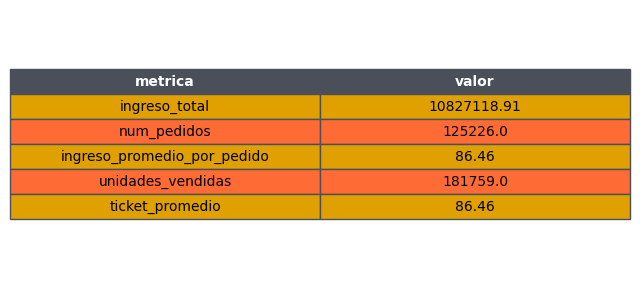

Métricas de ventas SUCESS!


In [185]:
# Métricas de ventas

df_metricas = pd.DataFrame.from_dict(resumen_metricas_ventas, orient='index', columns=['valor'])
df_metricas.index.name = 'metrica'
df_metricas.reset_index(inplace=True)


# Crear figura
fig, ax = plt.subplots(figsize=(8, 2 + len(df_metricas)*0.3))
ax.axis('off')

tabla = ax.table(
    cellText=df_metricas.values,
    colLabels=df_metricas.columns,
    cellLoc='center',
    loc='center'
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 1.5)

for (row, col), cell in tabla.get_celld().items():

    if row == 0:
        cell.set_facecolor(colores_tabla["header"])
        cell.set_text_props(color=colores_tabla["texto"], weight='bold')
        cell.set_edgecolor(colores_tabla["borde"])
    else:
        if row % 2 == 0:
            cell.set_facecolor(colores_tabla["par"])
        else:
            cell.set_facecolor(colores_tabla["impar"])
        cell.set_edgecolor(colores_tabla["borde"])

plt.show()

plt.savefig("../reports/img/metricas_ventas.png", dpi=300, bbox_inches='tight')
plt.close()

print('Métricas de ventas SUCESS!')

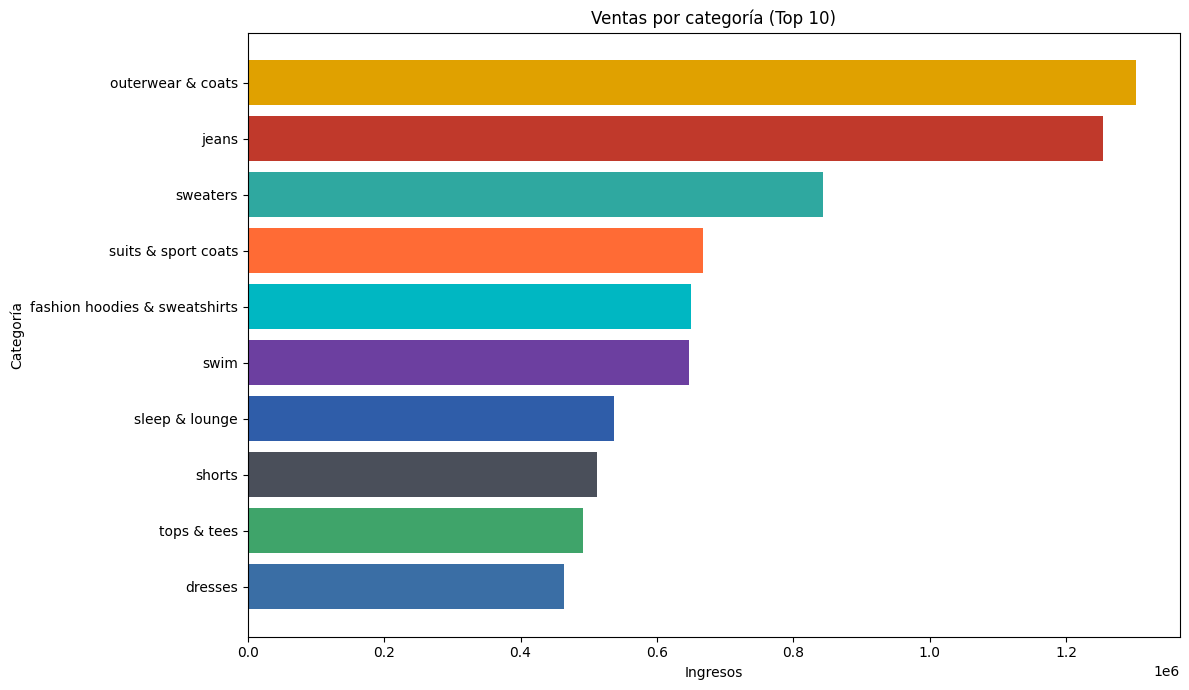

Gráfica Ventas por categoría SUCESS!


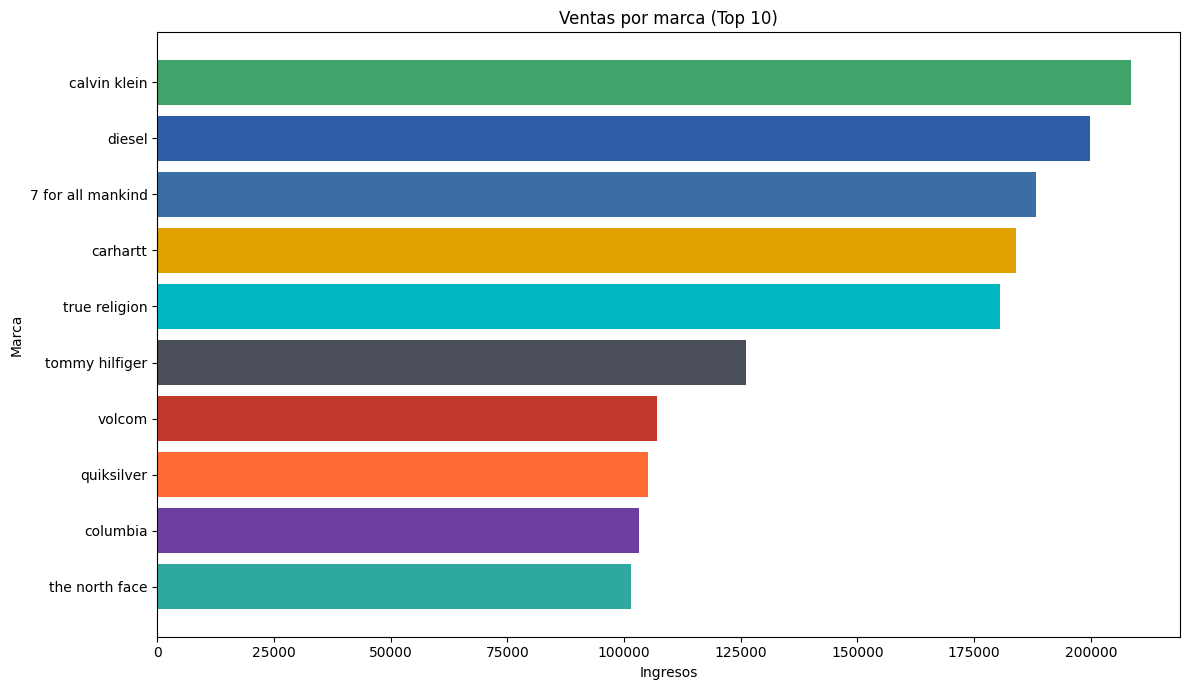

Gráfica Ventas por marca SUCESS!


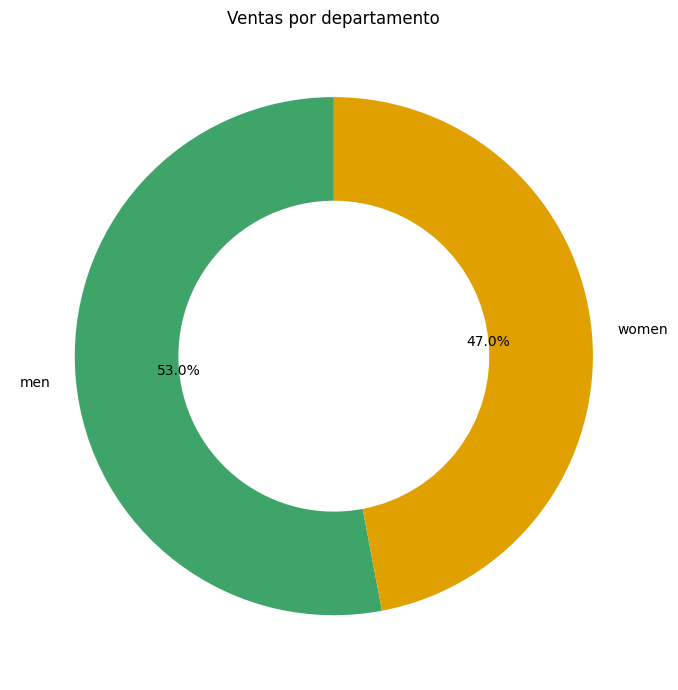

Gráfica Ventas por departamento SUCESS!


In [186]:
# Métricas por categoría / marca / departamento



# ============================
# 1) Ventas por categoría
# ============================
vals = ventas_categoria.head(10).sort_values().values
labs = ventas_categoria.head(10).sort_values().index

# Tomamos 10 colores de tu paleta
colores_usados = random.sample(mi_paleta_colores, 10)

plt.figure(figsize=(12, 7))

plt.barh(
    labs,
    vals,
    color=colores_usados
)

plt.title("Ventas por categoría (Top 10)")
plt.xlabel("Ingresos")
plt.ylabel("Categoría")

plt.tight_layout()
plt.show()

# Guardar imagen
plt.savefig("../reports/img/metricas_ventas_categoria.png", dpi=300, bbox_inches='tight')
plt.close()

print("Gráfica Ventas por categoría SUCESS!")

# ============================
# 2) Ventas por marca
# ============================
# Ventas por marca (Top 10)

vals = ventas_marca.head(10).sort_values().values
labs = ventas_marca.head(10).sort_values().index

# Tomamos 10 colores de tu paleta
colores_usados = random.sample(mi_paleta_colores, 10)

plt.figure(figsize=(12, 7))

plt.barh(
    labs,
    vals,
    color=colores_usados
)

plt.title("Ventas por marca (Top 10)")
plt.xlabel("Ingresos")
plt.ylabel("Marca")

plt.tight_layout()
plt.show()

# Guardar imagen
plt.savefig("../reports/img/metricas_ventas_marca.png", dpi=300, bbox_inches='tight')
plt.close()

print("Gráfica Ventas por marca SUCESS!")


# ============================
# 3) Ventas por departamento (dona)
# ============================

vals = ventas_departamento.values
labels = ventas_departamento.index

# Tomamos tantos colores como departamentos existan
colores_usados = random.sample(mi_paleta_colores, len(vals))

plt.figure(figsize=(7,7))

plt.pie(
    vals,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4},
    colors=colores_usados
)

plt.title("Ventas por departamento")
plt.tight_layout()
plt.show()

# Guardar imagen
plt.savefig("../reports/img/metricas_ventas_departamento.png", dpi=300, bbox_inches='tight')
plt.close()

print("Gráfica Ventas por departamento SUCESS!")


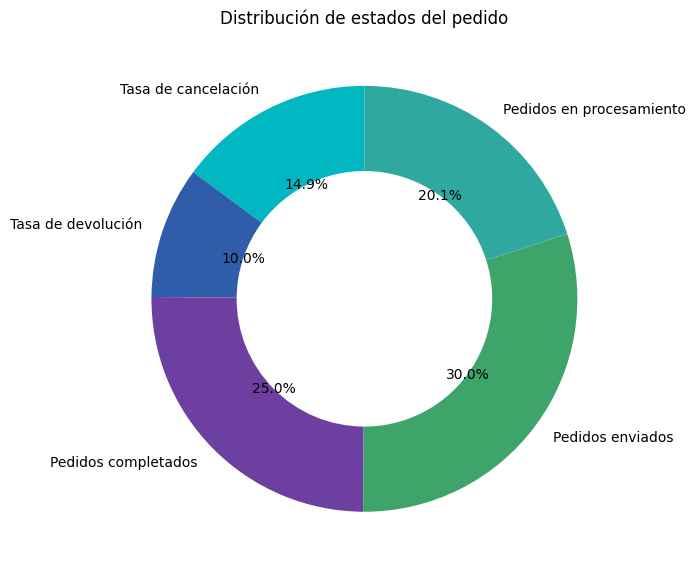

Gráfica Métricas Estado del Pedido SUCESS!


In [187]:

# Métricas de estado del pedido

# Datos desde tus objetos
labels = [
    "Tasa de cancelación",
    "Tasa de devolución",
    "Pedidos completados",
    "Pedidos enviados",
    "Pedidos en procesamiento"
]

vals = [
    tasa_cancelacion,
    tasa_devolucion,
    porcentaje_completados,
    porcentaje_shipped,
    porcentaje_processing
]

# Tomamos 5 colores de tu paleta
colores_usados = random.sample(mi_paleta_colores, 5)

plt.figure(figsize=(7,7))

plt.pie(
    vals,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4},
    colors=colores_usados
)

plt.title("Distribución de estados del pedido")
plt.tight_layout()

plt.show()

# Guardar imagen
plt.savefig("../reports/img/metricas_estado_pedido.png", dpi=300, bbox_inches='tight')
plt.close()

print("Gráfica Métricas Estado del Pedido SUCESS!")


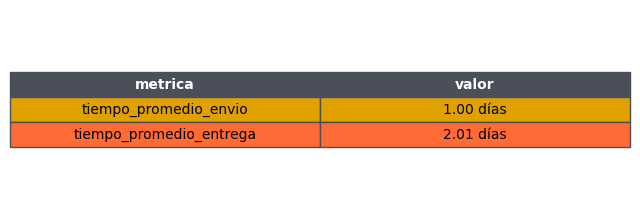

Métricas temporales SUCCESS!


In [188]:
# Métricas temporales básicas

resumen_metricas_temporales = {
    "tiempo_promedio_envio": tiempo_promedio_envio,
    "tiempo_promedio_entrega": tiempo_promedio_entrega
}

df_metricas_temporales = pd.DataFrame.from_dict(
    resumen_metricas_temporales,
    orient='index',
    columns=['valor']
)

df_metricas_temporales.index.name = 'metrica'
df_metricas_temporales.reset_index(inplace=True)

# Formateo a 2 decimales
df_metricas_temporales['valor'] = df_metricas_temporales['valor'].map(lambda x: f"{x:.2f} días")


# Crear figura
fig, ax = plt.subplots(figsize=(8, 2 + len(df_metricas_temporales)*0.3))
ax.axis('off')

tabla = ax.table(
    cellText=df_metricas_temporales.values,
    colLabels=df_metricas_temporales.columns,
    cellLoc='center',
    loc='center'
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 1.5)

for (row, col), cell in tabla.get_celld().items():

    if row == 0:
        cell.set_facecolor(colores_tabla["header"])
        cell.set_text_props(color=colores_tabla["texto"], weight='bold')
        cell.set_edgecolor(colores_tabla["borde"])
    else:
        if row % 2 == 0:
            cell.set_facecolor(colores_tabla["par"])
        else:
            cell.set_facecolor(colores_tabla["impar"])
        cell.set_edgecolor(colores_tabla["borde"])

plt.show()

plt.savefig("../reports/img/metricas_temporales.png", dpi=300, bbox_inches='tight')
plt.close()

print('Métricas temporales SUCCESS!')



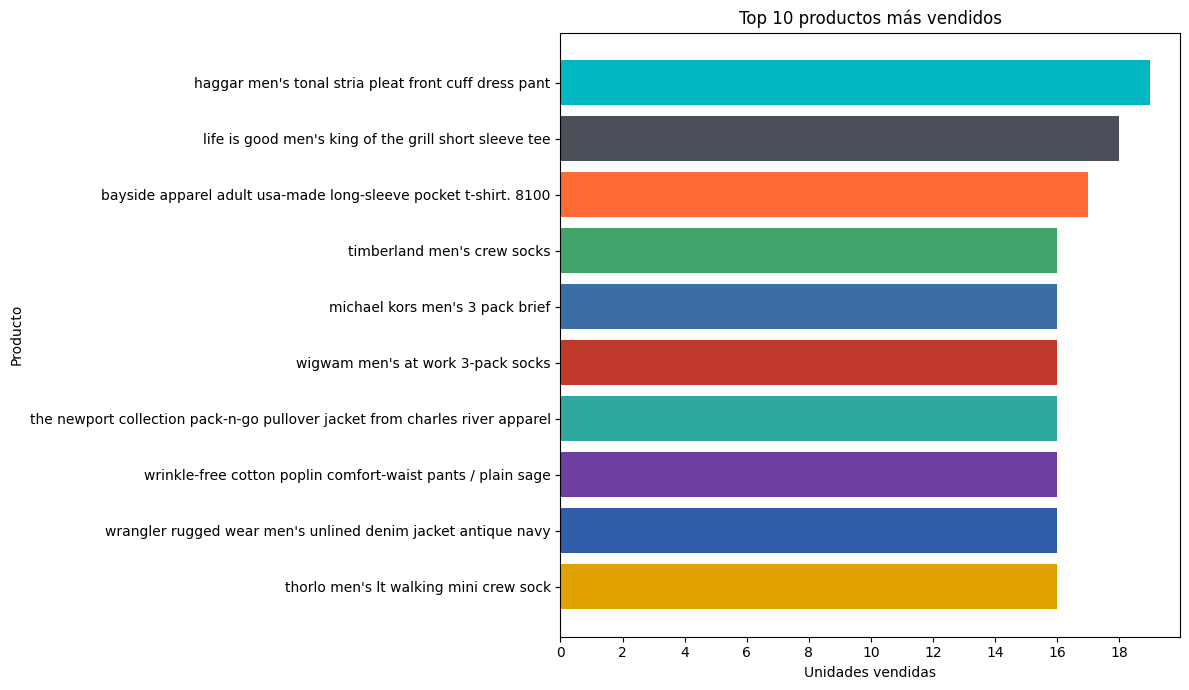

Gráfica Métricas Productos destacados SUCESS!


In [189]:

# Metricas Productos destacados

# Top 10 (ya ordenado de mayor a menor)
df_top10 = df_top_vendidos.head(10).copy()

# Para que el más vendido quede ARRIBA en la gráfica:
df_top10 = df_top10.sort_values('unidades_vendidas', ascending=True)

# Tomamos 10 colores de tu paleta
colores_usados = random.sample(mi_paleta_colores, 10)

plt.figure(figsize=(12, 7))

plt.barh(
    df_top10['name'],
    df_top10['unidades_vendidas'],
    color=colores_usados
)

plt.title("Top 10 productos más vendidos")
plt.xlabel("Unidades vendidas")
plt.ylabel("Producto")

# Escala del eje X solo con enteros
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()

plt.show()

# Guardar imagen
plt.savefig("../reports/img/metricas_productos_destacados.png", dpi=300, bbox_inches='tight')
plt.close()

print("Gráfica Métricas Productos destacados SUCESS!")


